# Predicting `fault_severity` — does the graph help?

The task is the Telstra competition: predict the multi-class `fault_severity`
(`0` none / `1` few / `2` many) of each disruption event. The competition metric is
**multi-class log loss**.

We train two models with the **same algorithm and the same train/holdout protocol**, changing
**only the feature set**:

* **Model A — local features only.** Everything we can know about an event *in isolation*: its
  alarm severity, and the log features / event types / resource types attached directly to it
  (including the full per-feature volume vector).
* **Model D — local + graph features.** Model A's features **plus** structural features computed
  with the **Neo4j Graph Data Science (GDS)** library over the **cascade graph**
  `(:Location)-[:NEXT_EVENT]->(:Location)`: the degree and PageRank centrality of each event's
  location, mapped back onto the event.

The dividing line is deliberate: Model A knows the event; Model D also knows *where its location
sits in the network's fault-cascade*. The gap between them is the value the graph topology adds.

**Algorithm.** Both models use **XGBoost** (`XGBClassifier`, `multi:softprob`) with identical
hyper-parameters, trained on the same fit splits and scored on the same holdouts — Model D is the
same learner, just handed the extra graph columns — so any difference is attributable to the
features, not the model.

> **Evaluation.** The graph's `test` events are **unlabeled** (the competition never released the
> true test `fault_severity`), so they can't be scored. We instead use a **repeated stratified
> holdout** carved from the labeled `train` set — 5 fresh 80/20 splits, averaged, with the
> across-seed spread reported so we can tell real gains from split-noise. The unlabeled `test`
> events are reserved for the final submission file.

> **Why only `NEXT_EVENT`?** The graph's other relationships (`LOGGED`, `TRIGGERED`,
> `ON_RESOURCE`, `HAS_ALARM`) merely mirror columns already in the local feature set, so
> centrality over them adds nothing the model doesn't have. `NEXT_EVENT` is the one genuinely
> *relational* structure — how faults move from site to site — and it carries signal local
> features can't see.
>
> **Leakage discipline.** The graph features are **unsupervised / purely structural** — computed
> from the shape of the cascade, never from `fault_severity` — so there is no label leakage, even
> though they are computed over train + test together.

In [26]:
# Setup
from dotenv import load_dotenv
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

from neo4j_analysis import Neo4jAnalysis

load_dotenv()
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

graph = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)
assert graph.verify_connection(), "Could not connect to Neo4j — run loader.ipynb first"
print("Connected.")

Connected.


## 1. Local features (Model A)

All pulled from Neo4j. Three pieces:

1. **Per-event aggregates** — alarm severity level, and counts / volume statistics over the
   directly-attached dimensions.
2. **Log-feature volume matrix** — one column per `LogFeature`, value = logged volume. This is
   the single richest local signal, so we keep all of it.
3. **One-hot resource & event types** — small enough to encode in full.

Every matrix is built over **all** events (train + test) so the columns line up, then split.

In [27]:
# 1a) Per-event scalar aggregates
events = graph.run_query_df('''
    MATCH (e:DisruptionEvent)
    OPTIONAL MATCH (e)-[:HAS_ALARM]->(s:SeverityType)
    OPTIONAL MATCH (e)-[lg:LOGGED]->(:LogFeature)
    WITH e, s.name AS severity_type,
         count(lg) AS num_log_features, sum(lg.volume) AS total_volume,
         max(lg.volume) AS max_volume, avg(lg.volume) AS mean_volume
    OPTIONAL MATCH (e)-[:ON_RESOURCE]->(r:ResourceType)
    WITH e, severity_type, num_log_features, total_volume, max_volume, mean_volume,
         count(DISTINCT r) AS num_resources
    OPTIONAL MATCH (e)-[:TRIGGERED]->(t:EventType)
    RETURN e.id AS id, e.dataset AS dataset, e.fault_severity AS fault_severity,
           severity_type, num_log_features, total_volume, max_volume, mean_volume,
           num_resources, count(DISTINCT t) AS num_event_types
    ORDER BY id
''')
# "severity_type 3" -> 3 ; it is an ordinal alarm level.
events["severity_level"] = events["severity_type"].str.extract(r"(\d+)").astype(int)
events = events.set_index("id")
print(events.shape)
events.head()

(18552, 10)


,dataset,fault_severity,severity_type,num_log_features,total_volume,max_volume,mean_volume,num_resources,num_event_types,severity_level
id,,,,,,,,,,
1,train,1.0,severity_type 1,3,5,2,1.666667,2,2,1
2,test,NaN,severity_type 2,5,5,1,1.000000,1,2,2
3,test,NaN,severity_type 1,1,2,2,2.000000,1,1,1
4,test,NaN,severity_type 4,1,3,3,3.000000,1,1,4
5,train,0.0,severity_type 2,2,17,11,8.500000,1,2,2


In [28]:
# 1b) Log-feature volume matrix (one column per LogFeature)
log_long = graph.run_query_to_df('''
    MATCH (e:DisruptionEvent)-[lg:LOGGED]->(f:LogFeature)
    RETURN e.id AS id, f.name AS feature, lg.volume AS volume
''')
log_wide = (log_long.pivot_table(index="id", columns="feature",
                                 values="volume", aggfunc="sum", fill_value=0)
            .add_prefix("vol__"))

# 1c) One-hot resource & event types
res_long = graph.run_query_to_df(
    "MATCH (e:DisruptionEvent)-[:ON_RESOURCE]->(r:ResourceType) "
    "RETURN e.id AS id, r.name AS resource"
)
res_oh = (pd.crosstab(res_long["id"], res_long["resource"]) > 0).astype(int).add_prefix("res__")

evt_long = graph.run_query_to_df(
    "MATCH (e:DisruptionEvent)-[:TRIGGERED]->(t:EventType) "
    "RETURN e.id AS id, t.name AS etype"
)
evt_oh = (pd.crosstab(evt_long["id"], evt_long["etype"]) > 0).astype(int).add_prefix("evt__")

LOCAL_SCALAR = ["severity_level", "num_log_features", "total_volume",
                "max_volume", "mean_volume", "num_resources", "num_event_types"]
local = (events[LOCAL_SCALAR]
         .join(log_wide, how="left")
         .join(res_oh, how="left")
         .join(evt_oh, how="left")
         .fillna(0))
print("Local feature matrix:", local.shape)

Local feature matrix: (18552, 456)


## 2. Graph features — the cascade projection (added in Model D)

Model D adds features from **Neo4j GDS**, but only over the cascade graph
`(:Location)-[:NEXT_EVENT]->(:Location)` — the one relationship in the schema that *isn't* already
a column in the local matrix. (The others — `LOGGED`, `TRIGGERED`, `ON_RESOURCE`, `HAS_ALARM` —
just connect an event to attributes we already one-hot encoded, so centrality over them re-encodes
what the model has.) `NEXT_EVENT` is genuinely relational: how faults move from site to site.

We project just the Location nodes and that one relationship, compute centrality, and map each
location's scores back onto the events that occurred there via `OCCURRED_AT`:

| GDS algorithm | Feature | Captures |
|---|---|---|
| `gds.degree` (directed) | `cas_out_deg` | how often faults flow *out* of the site |
| `gds.degree` (undirected) | `cas_tot_deg` | the site's overall connectivity in the cascade |
| `gds.pageRank` (directed) | `cas_pr_dir` | the site's importance in the directional flow |
| `gds.pageRank` (undirected) | `cas_pr_undir` | its importance ignoring direction |

These are unsupervised structural quantities — a leak-free proxy for location importance, with no
label ever touched. Degree + PageRank carry the signal on their own; embeddings (FastRP) and edge
weights were tried and neither helped, so the projection stays minimal.

In [29]:
# Location per event (the local matrix deliberately omits it) — needed to map cascade scores.
loc = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN e.id AS id, l.name AS location
''').set_index("id")["location"].reindex(events.index)

# Project ONLY the location cascade: (:Location)-[:NEXT_EVENT]->(:Location).
# Two projections: directed (NATURAL) for out-degree + directed PageRank, undirected for
# total degree + undirected PageRank. Plain unweighted centrality carries the full signal.
for g in ("cascade", "cascade_u"):
    graph.run_query(f"CALL gds.graph.drop('{g}', false) YIELD graphName RETURN graphName")

graph.run_query_single('''
    CALL gds.graph.project('cascade', ['Location'], ['NEXT_EVENT'], {memory: '2GB'})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
''')
graph.run_query_single('''
    CALL gds.graph.project('cascade_u', ['Location'], ['NEXT_EVENT'],
        {memory: '2GB', undirectedRelationshipTypes: ['NEXT_EVENT']})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
''')


def loc_stream(call, col):
    """Stream a Location-level centrality back, keyed by location name."""
    return graph.run_query_df(f'''
        CALL {call} YIELD nodeId, score
        WITH gds.util.asNode(nodeId) AS l, score WHERE l:Location
        RETURN l.name AS location, score AS {col}
    ''').set_index("location")


cas = (loc_stream("gds.degree.stream('cascade')",        "cas_out_deg")
       .join(loc_stream("gds.degree.stream('cascade_u')",   "cas_tot_deg"))
       .join(loc_stream("gds.pageRank.stream('cascade')",   "cas_pr_dir"))
       .join(loc_stream("gds.pageRank.stream('cascade_u')", "cas_pr_undir")))
for g in ("cascade", "cascade_u"):
    graph.run_query(f"CALL gds.graph.drop('{g}', false) YIELD graphName RETURN graphName")

# Map the Location-level scores down to each event via OCCURRED_AT.
cascade_df = cas.reindex(loc.values).set_axis(events.index).fillna(0)
CASCADE_COLS = list(cascade_df.columns)
print(f"{len(CASCADE_COLS)} cascade graph features:", CASCADE_COLS)
cascade_df.head(3)

4 cascade graph features: ['cas_out_deg', 'cas_tot_deg', 'cas_pr_dir', 'cas_pr_undir']


,cas_out_deg,cas_tot_deg,cas_pr_dir,cas_pr_undir
id,,,,
1,24.0,46.0,1.326915,1.454321
2,33.0,64.0,1.791453,1.851774
3,1.0,2.0,0.195787,0.200582


## 3. Train / test split & label

`train` events carry the `fault_severity` label; the graph's `test` events do not (the
competition never released them). Below we split the graph into its labeled `train` and unlabeled
`test` populations. We **evaluate** with a repeated stratified holdout carved from `train` (§4)
and reserve the unlabeled `test` events for the final submission file.

In [30]:
is_train = events["dataset"].eq("train")
train_ids = events.index[is_train]
test_ids = events.index[~is_train]
y = events.loc[train_ids, "fault_severity"].astype(int)

print(f"train={len(train_ids):,}  test={len(test_ids):,}")
print("class balance:", y.value_counts(normalize=True).round(3).to_dict())

train=7,381  test=11,171
class balance: {0: 0.648, 1: 0.253, 2: 0.098}


## 4. Evaluation harness

* **Split:** a **repeated** stratified holdout carved from the labeled `train` set — 5 fresh
  80/20 splits (one per seed), the same seeds for both models. A single holdout is noisy
  (≈ ±0.012 log loss here), so we average over seeds and report the spread; only differences
  larger than that spread are real. The graph's `test` events are unlabeled and reserved for §8.
* **Metric:** multi-class log loss (primary), plus accuracy and macro-F1, averaged over holdouts.
* **Model:** the same `XGBClassifier` for both — trained on each fit split, scored on its
  holdout — so the comparison is apples-to-apples.

In [31]:
# Repeated stratified holdout: for each seed, carve a fresh 80/20 split of the labeled
# train set, train, and score the holdout. Averaging over seeds turns the noisy single-
# split estimate into a stable one — and the spread (std) tells us which differences are
# real signal versus split-noise.
SEEDS = [42, 1, 7, 13, 21]


def make_clf():
    return XGBClassifier(
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=1.0, min_child_weight=5,
        tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
    )


def evaluate(feature_frame):
    """Repeated 80/20 stratified holdout over SEEDS. Returns:
      summary  – mean metrics across seeds, plus a *_std for each
      per_seed – the per-seed metrics frame
      y_pool, p_pool – pooled holdout labels & probabilities across all seeds (for plots)."""
    rows, y_pool, p_pool = [], [], []
    for seed in SEEDS:
        fit_ids, holdout_ids = train_test_split(
            train_ids, test_size=0.2, stratify=y, random_state=seed)
        clf = make_clf().fit(feature_frame.loc[fit_ids], y.loc[fit_ids])
        p = clf.predict_proba(feature_frame.loc[holdout_ids])
        y_hold = y.loc[holdout_ids]
        rows.append({
            "log_loss": log_loss(y_hold, p, labels=[0, 1, 2]),
            "accuracy": accuracy_score(y_hold, p.argmax(1)),
            "macro_f1": f1_score(y_hold, p.argmax(1), average="macro"),
        })
        y_pool.append(y_hold.values); p_pool.append(p)
    per_seed = pd.DataFrame(rows)
    summary = per_seed.mean().to_dict()
    summary.update({f"{k}_std": v for k, v in per_seed.std().to_dict().items()})
    return summary, per_seed, np.concatenate(y_pool), np.vstack(p_pool)

## 5. Model A — local features only

In [32]:
summary_A, seeds_A, y_pool_A, proba_A = evaluate(local)
print(f"Model A (local only) — mean over {len(SEEDS)} holdouts")
print({k: round(v, 4) for k, v in summary_A.items() if not k.endswith("_std")})
seeds_A.round(4)

Model A (local only) — mean over 5 holdouts
{'log_loss': 0.5498, 'accuracy': 0.7506, 'macro_f1': 0.6763}


,log_loss,accuracy,macro_f1
0,0.5261,0.7610,0.6984
1,0.5472,0.7563,0.6832
2,0.5601,0.7414,0.6696
3,0.5547,0.7475,0.6619
4,0.5608,0.7468,0.6681


## 6. Model D — local + cascade graph features

Same `XGBClassifier`, same fit/holdout split as Model A — the **only** change is that the feature
frame is `local` joined with the four cascade graph features from §2. So Model D is just Model A's
XGBoost with the graph signal added.

In [33]:
local_plus_cascade = local.join(cascade_df[CASCADE_COLS])
summary_D, seeds_D, y_pool_D, proba_D = evaluate(local_plus_cascade)
print(f"Model D (local + cascade graph features) — mean over {len(SEEDS)} holdouts")
print({k: round(v, 4) for k, v in summary_D.items() if not k.endswith("_std")})
seeds_D.round(4)

Model D (local + cascade graph features) — mean over 5 holdouts
{'log_loss': 0.5259, 'accuracy': 0.7643, 'macro_f1': 0.6951}


,log_loss,accuracy,macro_f1
0,0.5075,0.7651,0.7065
1,0.5261,0.7651,0.7019
2,0.5236,0.7678,0.7009
3,0.5283,0.7725,0.6991
4,0.5439,0.7508,0.6670


## 7. Does the graph help?

Lower log loss is better; higher accuracy / macro-F1 are better. The two models are identical
except for the cascade graph features, scored on the **same repeated holdouts**, so the gap is
exactly the value the graph topology adds. The error bars are the spread across seeds — the
graph improvement is several times larger than that spread, so it is real signal, not split-luck.
The pooled confusion matrices (over all holdout seeds) show where the lift lands — chiefly on the
harder, rarer non-zero fault classes that local features alone tend to miss.

,log_loss,accuracy,macro_f1,log_loss_std,log_loss_improvement_%
A: local only,0.5498,0.7506,0.6763,0.0143,0.0000
D: local + graph,0.5259,0.7643,0.6951,0.0130,4.3467


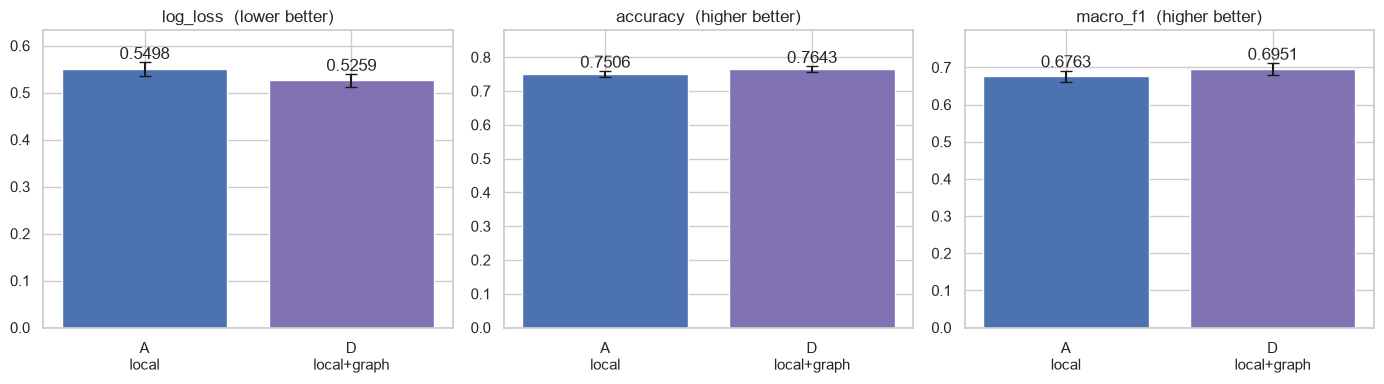

In [34]:
metrics = ["log_loss", "accuracy", "macro_f1"]
comp = pd.DataFrame({
    "A: local only": {m: summary_A[m] for m in metrics},
    "D: local + graph": {m: summary_D[m] for m in metrics},
}).T
comp["log_loss_std"] = [summary_A["log_loss_std"], summary_D["log_loss_std"]]
comp["log_loss_improvement_%"] = 100 * (summary_A["log_loss"] - comp["log_loss"]) / summary_A["log_loss"]
display(comp.round(4))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, met in enumerate(metrics):
    vals = [summary_A[met], summary_D[met]]
    errs = [summary_A[f"{met}_std"], summary_D[f"{met}_std"]]
    bars = ax[i].bar(["A\nlocal", "D\nlocal+graph"], vals, yerr=errs, capsize=4,
                     color=["#4C72B0", "#8172B3"])
    ax[i].bar_label(bars, fmt="%.4f")
    ax[i].set_title(met + ("  (lower better)" if met == "log_loss" else "  (higher better)"))
    ax[i].set_ylim(0, max(vals) * 1.15)
plt.tight_layout(); plt.show()

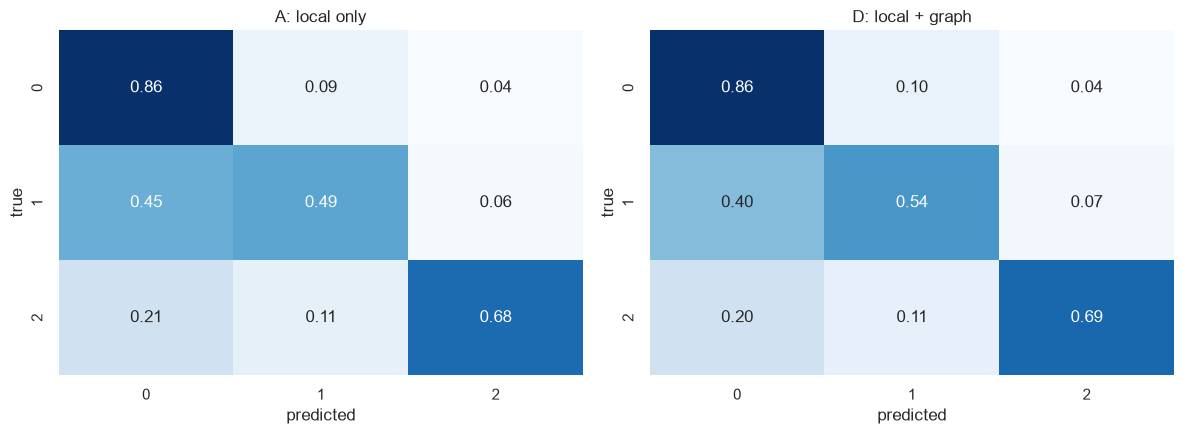

In [35]:
# Pooled confusion matrices over all holdout seeds (row-normalised)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, yp, proba, name in [(ax[0], y_pool_A, proba_A, "A: local only"),
                           (ax[1], y_pool_D, proba_D, "D: local + graph")]:
    cm = confusion_matrix(yp, proba.argmax(1), labels=[0, 1, 2], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=a,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], cbar=False)
    a.set_title(name); a.set_xlabel("predicted"); a.set_ylabel("true")
plt.tight_layout(); plt.show()

## 8. Final model & submission

Having validated on the holdout, we refit **Model D** (local + cascade graph features) on the
**entire labeled `train` set** (fit + holdout) and score the graph's **unlabeled `test`** events,
writing a `sample_submission`-shaped file — the artefact you would submit to the competition.

In [36]:
final = make_clf().fit(local_plus_cascade.loc[train_ids], y)
test_proba = final.predict_proba(local_plus_cascade.loc[test_ids])
test_proba = test_proba / test_proba.sum(axis=1, keepdims=True)

submission = pd.DataFrame(test_proba, columns=["predict_0", "predict_1", "predict_2"])
submission.insert(0, "id", test_ids.values)
out_path = os.path.join(os.getenv("DATA_DIR"), "submission_cascade_model.csv")
submission.to_csv(out_path, index=False)
print("Wrote", out_path)
submission.head()

Wrote .data/submission_cascade_model.csv


,id,predict_0,predict_1,predict_2
0,2,0.909027,0.090704,0.000269
1,3,0.349363,0.617252,0.033385
2,4,0.948018,0.050808,0.001174
3,7,0.568397,0.416201,0.015402
4,9,0.095814,0.857355,0.046831


## Takeaways

* The two models are identical except for the feature set — same XGBoost configuration, trained on
  the same fit splits and scored on the same repeated holdouts — so the difference is attributable
  to the graph features, not the learner.
* Evaluation uses a **repeated stratified holdout** (5 seeds, averaged) carved from the labeled
  `train` set, with the across-seed spread reported. A single split is noisy (≈ ±0.012 log loss),
  so averaging is what lets us trust small differences. The graph's `test` events are unlabeled
  (the competition withheld the answers), so they can only be predicted for submission.
* The graph block is produced with **Neo4j GDS** over a **single, focused projection**: the
  `(:Location)-[:NEXT_EVENT]->(:Location)` cascade. We compute `gds.degree` and `gds.pageRank`
  (directed and undirected) on the Location nodes and map them back to events via `OCCURRED_AT`.
* **Scope is what makes the graph pay off.** `NEXT_EVENT` is the one relationship that isn't
  already a column in `local`; centrality over it is an unsupervised, leak-free proxy for a
  location's role in the fault-cascade, and it beats local-only by several times the seed spread.
  Projecting the *whole* schema, or piling on more location-keyed features (within-location
  position, location label-smoothing), did **not** help — the location signal is saturated by the
  four centrality features.

In [37]:
graph.close()
print("Done — connection closed.")

Done — connection closed.
